In [1]:
import os
import pandas as pd
from pathlib import Path
import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import tqdm

In [2]:
os.chdir("D:/TUSZ_DataLake")
os.getcwd()

'D:\\TUSZ_DataLake'

In [4]:
def audit_dataset_labels(features_path: str):
    path = Path(features_path).resolve()
    all_files = list(path.rglob("*.parquet"))
    
    if not all_files:
        print(f"❌ No se encontraron archivos en: {features_path}")
        return

    print(f"🔍 Auditando {len(all_files)} sesiones...")
    
    total_counts = pd.Series(dtype=int)

    # 1. Recolección de datos
    for f in tqdm.tqdm(all_files, desc="Leyendo etiquetas"):
        try:
            df_label = pd.read_parquet(f, columns=['label'])
            counts = df_label['label'].value_counts()
            total_counts = total_counts.add(counts, fill_value=0)
        except Exception as e:
            print(f"\n⚠️ Error en {f.name}: {e}")

    total_samples = total_counts.sum()
    if total_samples == 0: return

    # --- 2. CONFIGURACIÓN DE GRUPOS CLÍNICOS ---
    mapping = {
        'bckg': 'BACKGROUND',
        # Focales
        'fnsz': 'FOCAL', 'cpsz': 'FOCAL', 'spsz': 'FOCAL',
        # Generalizadas
        'gnsz': 'GENERALIZED', 'tcsz': 'GENERALIZED', 'tnsz': 'GENERALIZED', 
        'absz': 'GENERALIZED', 'mysz': 'GENERALIZED'
    }

    # Creamos el dataframe detallado
    detailed_df = pd.DataFrame({
        'Ventanas': total_counts.astype(int),
        '%': (total_counts / total_samples * 100).map('{:.2f}%'.format)
    }).sort_values(by='Ventanas', ascending=False)

    # Creamos el dataframe por grupos
    # Mapeamos los índices de total_counts a sus grupos y sumamos
    group_counts = total_counts.groupby(total_counts.index.map(lambda x: mapping.get(x, 'OTRO'))).sum()
    group_df = pd.DataFrame({
        'Ventanas': group_counts.astype(int),
        '%': (group_counts / total_samples * 100).map('{:.2f}%'.format)
    }).sort_values(by='Ventanas', ascending=False)

    # --- 3. REPORTE FINAL ---
    print("\n" + "="*55)
    print("📋 TABLA 1: DESGLOSE DETALLADO (Subtipos)")
    print("="*55)
    print(detailed_df)
    
    print("\n" + "="*55)
    print("🧠 TABLA 2: RESUMEN POR GRANDES CLASES CLÍNICAS")
    print("="*55)
    print(group_df)
    
    print("\n" + "="*55)
    print(f"📈 Total Ventanas: {total_samples:,}")
    print(f"📂 Ruta: {features_path}")
    print("="*55)

if __name__ == "__main__":
    USER_PATH = r"04_TUSZ_Features_ML\version=v1_raw_labels"
    audit_dataset_labels(USER_PATH)

🔍 Auditando 1641 sesiones...


Leyendo etiquetas: 100%|███████████████████████████████████████████████████████████| 1641/1641 [01:51<00:00, 14.74it/s]


📋 TABLA 1: DESGLOSE DETALLADO (Subtipos)
       Ventanas       %
label                  
bckg    1246253  82.50%
fnsz     135811   8.99%
gnsz      88302   5.85%
cpsz      30892   2.05%
tcsz       4772   0.32%
spsz       1865   0.12%
mysz       1287   0.09%
absz        730   0.05%
tnsz        620   0.04%

🧠 TABLA 2: RESUMEN POR GRANDES CLASES CLÍNICAS
             Ventanas       %
label                        
BACKGROUND    1246253  82.50%
FOCAL          168568  11.16%
GENERALIZED     95711   6.34%

📈 Total Ventanas: 1,510,532.0
📂 Ruta: 04_TUSZ_Features_ML\version=v1_raw_labels


In [8]:
def get_comparative_audit_dfs(csv_path: str, parquet_path: str):
    # --- 1. CONFIGURACIÓN DE MAPEO CLÍNICO ---
    mapping = {
        'bckg': 'BACKGROUND',
        'fnsz': 'FOCAL', 'cpsz': 'FOCAL', 'spsz': 'FOCAL',
        'gnsz': 'GENERALIZED', 'tcsz': 'GENERALIZED', 'tnsz': 'GENERALIZED', 
        'absz': 'GENERALIZED', 'mysz': 'GENERALIZED'
    }

    # --- 2. AUDITORÍA NATURAL (DURACIÓN EN CSVs) ---
    print("🕒 Analizando distribución NATURAL (basada en tiempo total)...")
    csv_files = list(Path(csv_path).rglob("*.csv"))
    durations = {'BACKGROUND': 0.0, 'FOCAL': 0.0, 'GENERALIZED': 0.0}

    for f in tqdm.tqdm(csv_files, desc="Procesando CSVs"):
        try:
            df = pd.read_csv(f, comment='#')
            df.columns = df.columns.str.strip()
            df['duration'] = df['stop_time'] - df['start_time']
            df['mapped'] = df['label'].str.strip().map(lambda x: mapping.get(x, 'OTRO'))
            
            group_sums = df.groupby('mapped')['duration'].sum()
            for label, total_d in group_sums.items():
                if label in durations:
                    durations[label] += total_d
        except: continue

    # --- 3. AUDITORÍA PROCESADA (VENTANAS EN PARQUETS) ---
    print("\n📦 Analizando distribución PROCESADA (basada en ventanas)...")
    parquet_files = list(Path(parquet_path).rglob("*.parquet"))
    windows = {'BACKGROUND': 0, 'FOCAL': 0, 'GENERALIZED': 0}

    for f in tqdm.tqdm(parquet_files, desc="Procesando Parquets"):
        try:
            df_label = pd.read_parquet(f, columns=['label'])
            df_label['mapped'] = df_label['label'].map(lambda x: mapping.get(x, 'OTRO'))
            
            counts = df_label['mapped'].value_counts()
            for label, count in counts.items():
                if label in windows:
                    windows[label] += count
        except: continue

    # --- 4. CONSTRUCCIÓN DE LOS DATAFRAMES DE RETORNO ---
    # Tabla A: Natural (Segundos)
    total_sec = sum(durations.values())
    df_natural = pd.DataFrame({
        'Label': durations.keys(),
        'Segundos': durations.values(),
        'Prop_Original (%)': [round((v/total_sec*100), 2) for v in durations.values()]
    }).set_index('Label').sort_values(by='Segundos', ascending=False)

    # Tabla B: Procesada (Ventanas)
    total_win = sum(windows.values())
    df_processed = pd.DataFrame({
        'Label': windows.keys(),
        'Ventanas': windows.values(),
        'Prop_Procesada (%)': [round((v/total_win*100), 2) for v in windows.values()]
    }).set_index('Label').sort_values(by='Ventanas', ascending=False)

    return df_natural, df_processed

if __name__ == "__main__":
    CSV_PATH = r"D:\TUSZ_DataLake\01_Raw_Consolidated"
    PARQUET_PATH = r"C:\Users\jcami\Downloads\04_TUSZ_Features_ML\version=v1_raw_labels"
    
    # --- AQUÍ RECIBES TUS VARIABLES ---
    df_original, df_final = get_comparative_audit_dfs(CSV_PATH, PARQUET_PATH)
    
    # Ahora puedes hacer lo que quieras con ellas, por ejemplo:
    print("\n✅ Tablas listas en memoria.")
    print("\nEjemplo Tabla Original:")
    print(df_original.head())

🕒 Analizando distribución NATURAL (basada en tiempo total)...


Procesando CSVs: 100%|████████████████████████████████████████████████████████████| 7364/7364 [00:31<00:00, 230.40it/s]



📦 Analizando distribución PROCESADA (basada en ventanas)...


Procesando Parquets: 100%|███████████████████████████████████████████████████████████| 820/820 [00:39<00:00, 20.98it/s]


✅ Tablas listas en memoria.

Ejemplo Tabla Original:
                 Segundos  Prop_Original (%)
Label                                       
BACKGROUND   5.802758e+07              94.67
GENERALIZED  1.876454e+06               3.06
FOCAL        1.393748e+06               2.27


In [3]:
import pandas as pd
import tqdm
from pathlib import Path
import numpy as np

def get_detailed_duration_audit(csv_path: str):
    print("🕒 Analizando micro-distribución de duraciones (etiquetas específicas)...")
    csv_files = list(Path(csv_path).rglob("*.csv"))
    
    # Usaremos una lista para recolectar cada evento individualmente
    all_events = []

    for f in tqdm.tqdm(csv_files, desc="Procesando CSVs"):
        try:
            df = pd.read_csv(f, comment='#')
            df.columns = df.columns.str.strip()
            
            # Cálculo de duración por evento
            df['duration'] = df['stop_time'] - df['start_time']
            df['label'] = df['label'].str.strip()
            
            # Guardamos solo lo necesario: etiqueta y su duración
            all_events.append(df[['label', 'duration']])
        except Exception:
            continue

    # Consolidamos todo en un solo DataFrame de eventos
    df_all = pd.concat(all_events, ignore_index=True)

    # --- CÁLCULO DE ESTADÍSTICOS DESCRIPTIVOS ---
    def get_stats(group):
        q1 = group.quantile(0.25)
        q3 = group.quantile(0.75)
        return pd.Series({
            'Count': group.count(),
            'Mean': group.mean(),
            'SD': group.std(),
            'Min': group.min(),
            'P25': q1,
            'Median': group.median(),
            'P75': q3,
            'Max': group.max(),
            'IQR': q3 - q1,
            'Range': group.max() - group.min()
        })

    # Agrupamos por cada etiqueta específica sin mapear
    df_stats = df_all.groupby('label')['duration'].apply(get_stats).unstack()
    
    # Ordenar por conteo para ver cuáles son las más frecuentes
    return df_stats.sort_values(by='Count', ascending=False)

if __name__ == "__main__":
    CSV_PATH = r"D:\TUSZ_DataLake\01_Raw_Consolidated"
    
    df_detallado = get_detailed_duration_audit(CSV_PATH)
    
    print("\n📊 Auditoría de Duraciones por Etiqueta Clínica:")
    print(df_detallado.round(3).to_string())

🕒 Analizando micro-distribución de duraciones (etiquetas específicas)...


Procesando CSVs: 100%|█████████████████████████████████████████████████████████████| 7364/7364 [02:24<00:00, 51.05it/s]



📊 Auditoría de Duraciones por Etiqueta Clínica:
          Count     Mean       SD      Min      P25   Median      P75       Max      IQR     Range
label                                                                                             
bckg   131887.0  439.980  430.114    0.100  108.945  300.000  601.000  3598.000  492.055  3597.900
gnsz    23804.0   73.647  177.846    2.572   15.649   30.227   64.908  2448.000   49.259  2445.428
fnsz    19000.0   56.842  164.460    1.984   13.879   26.995   58.311  3601.000   44.432  3599.016
cpsz     3597.0   78.336  111.082    2.336   38.164   63.380   93.000  1303.000   54.836  1300.664
absz     2507.0    7.859    4.137    2.364    5.051    6.432    9.600    26.434    4.549    24.070
spsz      942.0   33.954    9.532   20.140   30.492   33.720   36.452    97.061    5.960    76.921
tcsz      857.0   74.375  176.923   12.893   45.005   56.344   74.292  2344.049   29.287  2331.156
tnsz      410.0   28.012   29.690    5.770   16.578   20.231

In [10]:
def plot_class_comparison(df_natural, df_processed):
    # Configuración de estilo
    sns.set_style("whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
    
    # Paleta de colores consistente (Clínica)
    # Background: Gris/Azul oscuro, Focal: Rojo, Generalized: Amarillo/Naranja
    palette = {"BACKGROUND": "#34495e", "FOCAL": "#e74c3c", "GENERALIZED": "#f1c40f"}
    
    # --- GRÁFICA 1: DISTRIBUCIÓN NATURAL ---
    sns.barplot(
        x=df_natural.index, 
        y=df_natural['Prop_Original (%)'], 
        ax=ax1, 
        palette=palette
    )
    ax1.set_title("1. DISTRIBUCIÓN NATURAL\n(Segundos reales en CSV)", fontsize=14, fontweight='bold', pad=15)
    ax1.set_ylabel("Proporción (%)", fontsize=12)
    ax1.set_xlabel("Clase Clínica", fontsize=12)
    
    # Añadir etiquetas de porcentaje sobre las barras
    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.2f}%', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points',
                     fontweight='bold')

    # --- GRÁFICA 2: DISTRIBUCIÓN PROCESADA ---
    sns.barplot(
        x=df_processed.index, 
        y=df_processed['Prop_Procesada (%)'], 
        ax=ax2, 
        palette=palette
    )
    ax2.set_title("2. DISTRIBUCIÓN CON DATA AUGMENTATION\n(Ventanas generadas en Parquet)", fontsize=14, fontweight='bold', pad=15)
    ax2.set_ylabel("") # Quitamos el label porque comparten el eje Y
    ax2.set_xlabel("Clase Clínica", fontsize=12)

    # Añadir etiquetas de porcentaje sobre las barras
    for p in ax2.patches:
        ax2.annotate(f'{p.get_height():.2f}%', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points',
                     fontweight='bold')

    # Ajustes finales
    plt.suptitle("Impacto del Ventaneo Diferencial en el Balance de Clases (TUSZ)", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

C:\Users\jcami\AppData\Local\Temp\ipykernel_29900\1757476778.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\jcami\AppData\Local\Temp\ipykernel_29900\1757476778.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


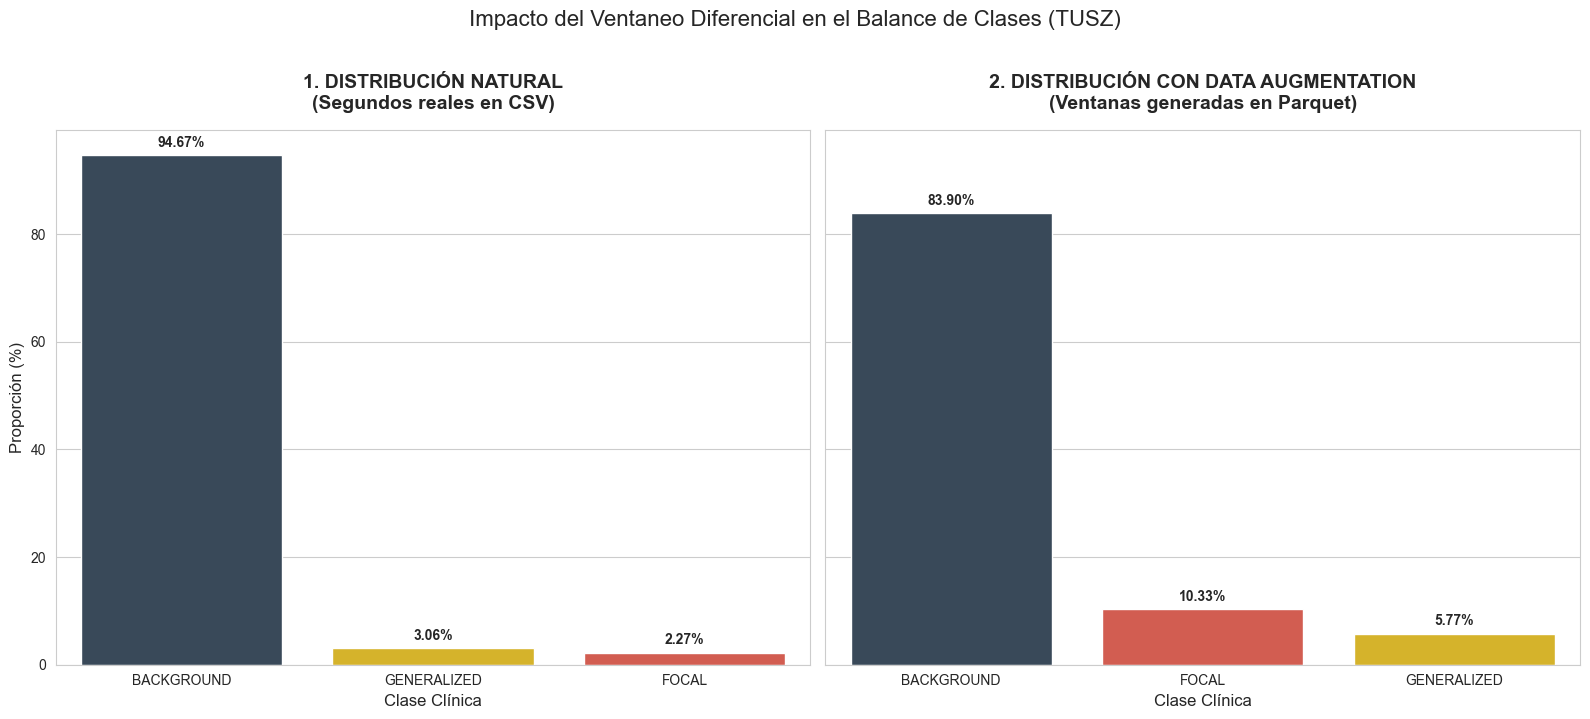

In [11]:
plot_class_comparison(df_original, df_final)

In [ ]:
print(df_original)
print(df_final)

In [3]:
3.06/2.27

1.3480176211453745

In [4]:
10.33/5.77

1.7902946273830158

📄 Inspeccionando archivo: session_s007_2015.parquet
📂 Ruta: D:\TUSZ_DataLake\04_TUSZ_Features_ML\version=v1_raw_labels\81

📊 Total de columnas: 1086
------------------------------
📋 PRIMERAS 20 COLUMNAS:
['start_time', 'end_time', 'label', 'spatial_ASI', 'spatial_APG', 'spatial_GFP', 'Fp1-F7_A5_rms', 'Fp1-F7_A5_pwr', 'Fp1-F7_A5_ll', 'Fp1-F7_A5_teo', 'Fp1-F7_A5_mean', 'Fp1-F7_A5_std', 'Fp1-F7_A5_skew', 'Fp1-F7_A5_kurt', 'Fp1-F7_A5_ent', 'Fp1-F7_A5_dkatz', 'Fp1-F7_D5_rms', 'Fp1-F7_D5_pwr', 'Fp1-F7_D5_ll', 'Fp1-F7_D5_teo']

⚠️ Columnas con NaNs en ESTE archivo: 0
♾️ Total de valores Infinitos detectados: 0

📈 Graficando distribución de: spatial_ASI


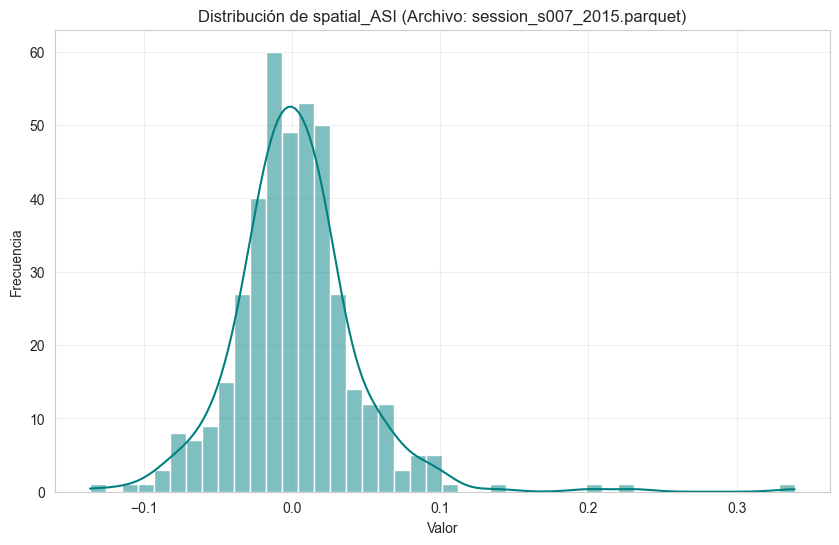

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import random

def inspect_random_parquet(features_path):
    path = Path(features_path).resolve()
    all_files = list(path.rglob("*.parquet"))
    
    if not all_files:
        print(f"❌ No se encontraron archivos en: {features_path}")
        return

    # 1. Elegir un archivo al azar
    random_file = random.choice(all_files)
    print(f"📄 Inspeccionando archivo: {random_file.name}")
    print(f"📂 Ruta: {random_file.parent}\n")

    # 2. Cargar el dataframe
    df = pd.read_parquet(random_file)
    
    # --- ANÁLISIS DE COLUMNAS ---
    print(f"📊 Total de columnas: {len(df.columns)}")
    print("-" * 30)
    print("📋 PRIMERAS 20 COLUMNAS:")
    print(df.columns[:20].tolist())
    
    # --- BÚSQUEDA DE CULPABLES (NaNs/Infs) ---
    nan_counts = df.isna().sum()
    inf_counts = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
    
    cols_with_nan = nan_counts[nan_counts > 0]
    print(f"\n⚠️ Columnas con NaNs en ESTE archivo: {len(cols_with_nan)}")
    if not cols_with_nan.empty:
        print(cols_with_nan)
    print(f"♾️ Total de valores Infinitos detectados: {inf_counts}")

    # 3. Graficar distribución de una feature
    # Buscamos la primera columna que no sea de metadata
    metadata_cols = ['label', 'start_time', 'end_time', 'patient_id', 'patient_num_id']
    features = [c for c in df.columns if c not in metadata_cols]
    
    if features:
        feature_to_plot = features[0] # Puedes cambiar esto por el nombre que quieras
        print(f"\n📈 Graficando distribución de: {feature_to_plot}")
        
        plt.figure(figsize=(10, 6))
        sns.histplot(df[feature_to_plot].replace([np.inf, -np.inf], np.nan).dropna(), 
                     kde=True, color='teal')
        plt.title(f"Distribución de {feature_to_plot} (Archivo: {random_file.name})")
        plt.xlabel("Valor")
        plt.ylabel("Frecuencia")
        plt.grid(alpha=0.3)
        plt.show()
    else:
        print("❌ No se encontraron columnas de features matemáticas.")

if __name__ == "__main__":
    USER_PATH = r"04_TUSZ_Features_ML\version=v1_raw_labels"
    inspect_random_parquet(USER_PATH)

In [21]:
import pandas as pd
import numpy as np
from pathlib import Path
import tqdm

def run_detailed_forensic_auditor(features_path: str):
    path = Path(features_path).resolve()
    all_files = list(path.rglob("*.parquet"))
    
    # Estructuras para devolver
    pacientes_mismatch = {} # {patient_id: [sesiones_con_columnas_raras]}
    variables_con_nans = {} # {columna: [lista_de_archivos_donde_falla]}
    reporte_pacientes_nan = set() # Pacientes que tienen al menos un NaN
    
    print(f"🕵️ Iniciando auditoría forense detallada...")

    # 1. Definir el estándar (usamos el primero como referencia)
    ref_df = pd.read_parquet(all_files[0])
    ref_cols = set(ref_df.columns)
    
    for f in tqdm.tqdm(all_files, desc="Escaneando"):
        try:
            # Extraemos el ID del paciente (asumiendo ruta: .../ID_PACIENTE/archivo.parquet)
            patient_id = f.parent.name
            df = pd.read_parquet(f)
            current_cols = set(df.columns)
            
            # --- CHEQUEO 1: Esquema (Columnas diferentes) ---
            if current_cols != ref_cols:
                if patient_id not in pacientes_mismatch:
                    pacientes_mismatch[patient_id] = []
                
                diff = {
                    "sesion": f.name,
                    "faltantes": list(ref_cols - current_cols),
                    "extras": list(current_cols - ref_cols)
                }
                pacientes_mismatch[patient_id].append(diff)

            # --- CHEQUEO 2: NaNs (Variables tóxicas) ---
            nan_series = df.isna().sum()
            if nan_series.sum() > 0:
                reporte_pacientes_nan.add(patient_id)
                cols_con_problemas = nan_series[nan_series > 0].index.tolist()
                
                for col in cols_con_problemas:
                    if col not in variables_con_nans:
                        variables_con_nans[col] = []
                    variables_con_nans[col].append(f"{patient_id}/{f.name}")

        except Exception as e:
            print(f"❌ Error en {f.name}: {e}")

    return pacientes_mismatch, variables_con_nans, list(reporte_pacientes_nan)

if __name__ == "__main__":
    PATH = r"04_TUSZ_Features_ML\version=v1_raw_labels"
    mismatch, nan_vars, nan_patients = run_detailed_forensic_auditor(PATH)
    
    # --- Diagnóstico post-ejecución ---
    print("\n" + "="*60)
    print("🔍 DIAGNÓSTICO DE PACIENTES")
    print("="*60)
    print(f"🆔 Pacientes con esquemas inconsistentes: {len(mismatch)}")
    print(f"🆔 Pacientes con datos corruptos (NaNs): {len(nan_patients)}")
    
    if nan_vars:
        print("\n💀 VARIABLES AFECTADAS POR NaNs (Top 5):")
        sorted_vars = sorted(nan_vars.items(), key=lambda x: len(x[1]), reverse=True)
        for var, archivos in sorted_vars[:5]:
            print(f"- {var}: falla en {len(archivos)} archivos.")

🕵️ Iniciando auditoría forense detallada...


Escaneando: 100%|██████████████████████████████████████████████████████████████████| 1641/1641 [02:49<00:00,  9.70it/s]


🔍 DIAGNÓSTICO DE PACIENTES
🆔 Pacientes con esquemas inconsistentes: 26
🆔 Pacientes con datos corruptos (NaNs): 13

💀 VARIABLES AFECTADAS POR NaNs (Top 5):
- Fz-Cz_A5_rms: falla en 15 archivos.
- Fz-Cz_A5_pwr: falla en 15 archivos.
- Fz-Cz_A5_ll: falla en 15 archivos.
- Fz-Cz_A5_teo: falla en 15 archivos.
- Fz-Cz_A5_mean: falla en 15 archivos.


In [5]:
def get_error_matrix(features_path: str):
    path = Path(features_path).resolve()
    all_files = list(path.rglob("*.parquet"))
    
    # Lista para construir la matriz de errores
    error_log = []
    
    # 1. Definir esquema de referencia (usamos el primer archivo)
    ref_df = pd.read_parquet(all_files[0])
    ref_cols = set(ref_df.columns)
    
    print(f"🕵️ Escaneando {len(all_files)} archivos para construir la matriz de fallos...")

    for f in tqdm.tqdm(all_files, desc="Auditoría"):
        try:
            patient_id = f.parent.name
            session_id = f.name
            df = pd.read_parquet(f)
            current_cols = set(df.columns)
            
            has_mismatch = current_cols != ref_cols
            nan_series = df.isna().sum()
            has_nans = nan_series.sum() > 0
            
            # Solo registramos si hay algún problema
            if has_mismatch or has_nans:
                # Identificar columnas faltantes o con NaNs
                missing_cols = list(ref_cols - current_cols)
                extra_cols = list(current_cols - ref_cols)
                nan_cols = nan_series[nan_series > 0].index.tolist()
                
                error_log.append({
                    "paciente": patient_id,
                    "sesion": session_id,
                    "error_esquema": has_mismatch,
                    "tiene_nans": has_nans,
                    "columnas_faltantes": missing_cols if missing_cols else None,
                    "columnas_extra": extra_cols if extra_cols else None,
                    "columnas_con_nan": nan_cols if nan_cols else None,
                    "total_nans": int(nan_series.sum())
                })

        except Exception as e:
            error_log.append({
                "paciente": f.parent.name,
                "sesion": f.name,
                "error_esquema": "CRITICAL_ERROR",
                "tiene_nans": "UNKNOWN",
                "mensaje_error": str(e)
            })

    # Convertir a DataFrame (tu "matriz" de fallos)
    df_errores = pd.DataFrame(error_log)
    return df_errores

if __name__ == "__main__":
    PATH = r"04_TUSZ_Features_ML\version=v1_raw_labels"
    
    # --- Ejecución y obtención de la variable ---
    matriz_fallos = get_error_matrix(PATH)
    
    # --- Visualización de resultados ---
    if not matriz_fallos.empty:
        print("\n" + "="*80)
        print("📋 MATRIZ DE SESIONES CON FALLOS")
        print("="*80)
        # Mostramos las primeras columnas para inspección rápida
        print(matriz_fallos[['paciente', 'sesion', 'error_esquema', 'tiene_nans', 'total_nans']].to_string(index=False))
        
        # Guardar para inspección detallada si se desea
        # matriz_fallos.to_csv("diagnostico_errores_tusz.csv", index=False)
    else:
        print("\n✅ ¡Increíble! No se encontraron fallos en ningún archivo.")

🕵️ Escaneando 1641 archivos para construir la matriz de fallos...


Auditoría: 100%|███████████████████████████████████████████████████████████████████| 1641/1641 [03:50<00:00,  7.11it/s]


📋 MATRIZ DE SESIONES CON FALLOS
paciente                    sesion  error_esquema  tiene_nans  total_nans
      10 session_s008_2013.parquet           True        True      222240
     121 session_s010_2016.parquet           True       False           0
     140 session_s002_2012.parquet           True        True      266880
     166 session_s003_2016.parquet           True       False           0
     166 session_s005_2016.parquet           True       False           0
     166 session_s004_2016.parquet           True        True     2233140
     339 session_s010_2014.parquet           True       False           0
     339 session_s008_2014.parquet           True        True      282480
     339 session_s033_2016.parquet           True       False           0
     339 session_s030_2016.parquet           True        True      880380
     339 session_s022_2016.parquet           True       False           0
     339 session_s023_2016.parquet           True       False           0
     

## Importancia

In [6]:
pacientes_excluidos = matriz_fallos['paciente'].unique().tolist()
print(f"🚫 Omitiendo temporalmente {len(pacientes_excluidos)} pacientes con inconsistencias.")

🚫 Omitiendo temporalmente 26 pacientes con inconsistencias.


In [5]:
from sklearn.feature_selection import mutual_info_classif

def get_top_features_clean_subset(features_path, excluded_ids, samples_per_file=40):
    path = Path(features_path).resolve()
    all_files = list(path.rglob("*.parquet"))
    
    # Mapeo de clases
    mapping = {'bckg': 'BACKGROUND', 'fnsz': 'FOCAL', 'gnsz': 'GENERALIZED'}
    sampled_data = []

    print(f"🧪 Iniciando muestreo sobre el subconjunto limpio...")
    for f in tqdm.tqdm(all_files, desc="Filtrando y Muestreando"):
        patient_id = f.parent.name
        
        # Saltamos si el paciente está en la lista de fallos
        if patient_id in excluded_ids:
            continue
            
        try:
            df = pd.read_parquet(f)
            if df.empty: continue
            
            # Etiquetado
            df['target'] = df['label'].map(lambda x: mapping.get(x, 'BACKGROUND'))
            
            # Muestra estratificada
            n = min(len(df), samples_per_file)
            sampled_data.append(df.sample(n=n, random_state=42))
        except:
            continue

    # Consolidación de la muestra "pura"
    full_sample = pd.concat(sampled_data, ignore_index=True)
    
    # Limpieza de columnas no matemáticas
    cols_drop = ['label', 'target', 'start_time', 'end_time', 'patient_id', 'patient_num_id']
    X = full_sample.drop(columns=[c for c in cols_drop if c in full_sample.columns])
    y = full_sample['target']

    # ELIMINACIÓN DE SEGURIDAD: Si alguna columna quedó con NaNs residuales (muy raro ahora)
    X = X.dropna(axis=1)

    print(f"🚀 Calculando Importancia (MI) sobre {len(X)} ventanas y {X.shape[1]} features...")
    mi_scores = mutual_info_classif(X, y, discrete_features=False, random_state=42)
    
    ranking = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
    return ranking.head(15)

if __name__ == "__main__":
    # Ejecutamos usando la lista de pacientes excluidos de la matriz de fallos
    top_15_final = get_top_features_clean_subset(
        r"04_TUSZ_Features_ML\version=v1_raw_labels", 
        pacientes_excluidos
    )
    
    print("\n" + "="*50)
    print("🏆 TOP 15 FEATURES (Subconjunto de Datos Limpios)")
    print("="*50)
    print(top_15_final)

🧪 Iniciando muestreo sobre el subconjunto limpio...


Filtrando y Muestreando: 100%|█████████████████████████████████████████████████████| 1641/1641 [03:10<00:00,  8.59it/s]


🚀 Calculando Importancia (MI) sobre 56169 ventanas y 1083 features...

🏆 TOP 15 FEATURES (Subconjunto de Datos Limpios)
P3-O1_A5_ll     0.018457
P4-O2_A5_ll     0.018039
T6-O2_A5_ll     0.017190
Cz-Pz_A5_ll     0.017166
C4-P4_D5_ll     0.016559
C3-P3_A5_ll     0.016453
P3-O1_D5_ll     0.015894
P4-O2_D5_ll     0.015582
C4-P4_A5_ll     0.014920
T5-O1_A5_ll     0.014476
C3-P3_D5_ll     0.014453
F3-C3_D5_ll     0.014150
F8-T4_D5_ll     0.013503
Fp1-F7_D5_ll    0.013441
Cz-Pz_D5_ll     0.013328
dtype: float64


In [6]:
def extract_queen_feature_data(features_path, queen_feature, excluded_ids):
    path = Path(features_path).resolve()
    all_files = list(path.rglob("*.parquet"))
    
    mapping = {
        'bckg': 'BACKGROUND',
        'fnsz': 'FOCAL', 'cpsz': 'FOCAL', 'spsz': 'FOCAL',
        'gnsz': 'GENERALIZED', 'tcsz': 'GENERALIZED', 'tnsz': 'GENERALIZED', 
        'absz': 'GENERALIZED', 'mysz': 'GENERALIZED'
    }

    data_accumulator = []

    print(f"👑 Extrayendo la gema: {queen_feature}...")
    
    for f in tqdm.tqdm(all_files, desc="Procesando pacientes"):
        patient_id = f.parent.name
        
        # Saltar pacientes excluidos
        if patient_id in excluded_ids:
            continue
            
        try:
            # Leemos solo las dos columnas necesarias: la feature y la etiqueta
            df = pd.read_parquet(f, columns=['label', queen_feature])
            
            # Mapeo de clases
            df['class'] = df['label'].map(lambda x: mapping.get(x, 'BACKGROUND'))
            
            # Limpieza de NaNs (si los hubiera en este archivo)
            df = df.dropna(subset=[queen_feature])
            
            # Guardamos el ID del paciente para trazabilidad
            df['patient_id'] = patient_id
            
            data_accumulator.append(df[['patient_id', 'class', queen_feature]])
            
        except Exception:
            # Si un archivo específico no tiene la columna (mismatch), lo saltamos
            continue

    # Consolidación final
    df_queen = pd.concat(data_accumulator, ignore_index=True)
    
    print("\n" + "="*50)
    print(f"✅ Extracción completada.")
    print(f"📊 Total de ventanas recuperadas: {len(df_queen):,}")
    print(f"🧠 Clases detectadas: {df_queen['class'].unique()}")
    print("="*50)
    
    return df_queen

👑 Extrayendo la gema: P3-O1_A5_ll...


Procesando pacientes: 100%|████████████████████████████████████████████████████████| 1641/1641 [01:35<00:00, 17.23it/s]



✅ Extracción completada.
📊 Total de ventanas recuperadas: 1,095,264
🧠 Clases detectadas: ['BACKGROUND' 'FOCAL' 'GENERALIZED']


In [ ]:
FEATURE_NAME = 'P3-O1_A5_ll'
df_queen = extract_queen_feature_data(
    r"04_TUSZ_Features_ML\version=v1_raw_labels", 
    FEATURE_NAME, 
    pacientes_excluidos
)

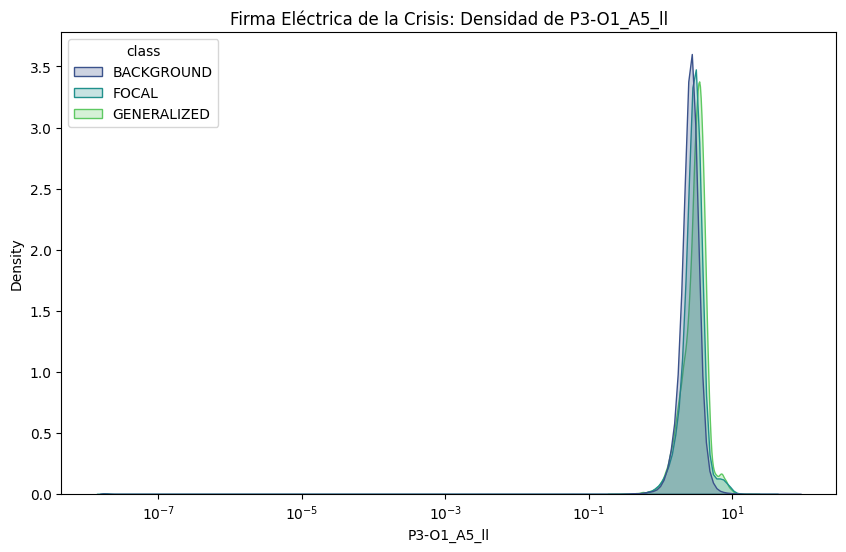

In [7]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_queen, x=FEATURE_NAME, hue='class', fill=True, common_norm=False, palette='viridis', log_scale=True)
plt.title(f"Firma Eléctrica de la Crisis: Densidad de {FEATURE_NAME}")
plt.show()

In [8]:
stats = df_queen.groupby('class')[FEATURE_NAME].agg(['mean', 'std', 'median', 'count'])
print(stats)

                 mean       std    median   count
class                                            
BACKGROUND   2.640363  0.830107  2.576845  895322
FOCAL        2.978263  1.111427  2.877520  128943
GENERALIZED  3.173275  1.177202  3.144273   70999


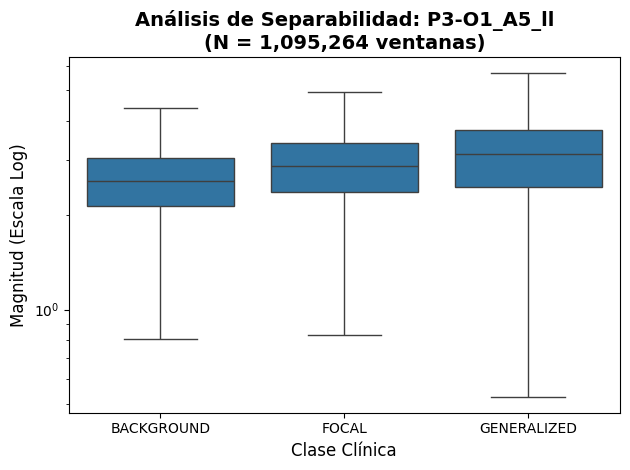

In [13]:
ax = sns.boxplot(
        data=df_queen, 
        x='class', 
        y=FEATURE_NAME, 
        showfliers=False,
        order=['BACKGROUND', 'FOCAL', 'GENERALIZED']
    )
    
# Escala logarítmica (Vital para Line Length)
plt.yscale('log')
    
    # Títulos y etiquetas
plt.title(f"Análisis de Separabilidad: {FEATURE_NAME}\n(N = {len(df_queen):,} ventanas)", fontsize=14, fontweight='bold')
plt.ylabel("Magnitud (Escala Log)", fontsize=12)
plt.xlabel("Clase Clínica", fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
from scipy import stats
def run_non_parametric_stats(df, feature_name):
    # 1. Preparar los grupos
    groups = [df[df['class'] == c][feature_name].values for c in df['class'].unique()]
    
    # 2. Test de Kruskal-Wallis (H-test)
    h_stat, p_val = stats.kruskal(*groups)
    
    # 3. Cálculo del Tamaño del Efecto (Epsilon-squared: epsilon^2)
    # Fórmula: epsilon^2 = H / ((n^2 - 1) / (n + 1)) = H / (n - 1)
    n_total = len(df)
    epsilon_sq = h_stat / (n_total - 1)
    
    print("="*60)
    print(f"🔬 ANÁLISIS ESTADÍSTICO PARA: {feature_name}")
    print("="*60)
    print(f"Estadístico H (Kruskal-Wallis): {h_stat:.4f}")
    print(f"p-valor: {p_val:.4e}")
    print(f"Tamaño del efecto (epsilon^2): {epsilon_sq:.6f}")
    print("-" * 60)
    
    # Interpretación del tamaño del efecto (Cohen's rules of thumb para epsilon^2)
    if epsilon_sq < 0.01:
        interpretacion = "Despreciable (Negligible)"
    elif epsilon_sq < 0.06:
        interpretacion = "Pequeño"
    elif epsilon_sq < 0.14:
        interpretacion = "Mediano"
    else:
        interpretacion = "Grande"
        
    print(f"Interpretación del Efecto: {interpretacion}")
    
    # 4. Comparación de Medianas
    medianas = df.groupby('class')[feature_name].median()
    print("\n📋 MEDIANAS POR CLASE:")
    print(medianas)
    print("="*60)

In [15]:
run_non_parametric_stats(df_queen, 'P3-O1_A5_ll')

🔬 ANÁLISIS ESTADÍSTICO PARA: P3-O1_A5_ll
Estadístico H (Kruskal-Wallis): 33534.9464
p-valor: 0.0000e+00
Tamaño del efecto (epsilon^2): 0.030618
------------------------------------------------------------
Interpretación del Efecto: Pequeño

📋 MEDIANAS POR CLASE:
class
BACKGROUND     2.576845
FOCAL          2.877520
GENERALIZED    3.144273
Name: P3-O1_A5_ll, dtype: float32


# Correlación

In [8]:
def calcular_correlacion_top15(path_features, top_features, lista_excluidos):
    path = Path(path_features).resolve()
    all_files = list(path.rglob("*.parquet"))
    
    data_list = []
    
    print(f"📡 Procesando archivos para el Top 15...")
    
    # 1. Recolección selectiva y eficiente
    for f in tqdm.tqdm(all_files, desc="Leyendo Parquets"):
        # Extraer ID del paciente de la ruta (asumiendo estructura de carpetas)
        patient_id = f.parent.name
        
        # Filtrar pacientes excluidos
        if patient_id in lista_excluidos:
            continue
            
        try:
            # Cargamos ÚNICAMENTE las 15 columnas de interés
            df = pd.read_parquet(f, columns=top_features)
            
            # Tomamos una muestra (subsampling) para agilizar y 
            # no saturar la RAM con millones de filas
            if len(df) > 100:
                data_list.append(df.sample(n=100, random_state=42))
            else:
                data_list.append(df)
        except Exception:
            # Si algún archivo falla o no tiene las columnas, se ignora
            continue

    # 2. Consolidar el DataFrame
    full_df = pd.concat(data_list, ignore_index=True)
    
    # 3. Calcular Correlación de Spearman
    print("\n🧮 Calculando matriz de Spearman...")
    corr_matrix = full_df.corr(method='spearman')
    
    # 4. Visualización con Heatmap profesional
    plt.figure(figsize=(14, 11))
    sns.set_theme(style="white")
    
    # Máscara para la mitad superior (triángulo superior es redundante)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Mapa de calor
    heatmap = sns.heatmap(
        corr_matrix, 
        mask=mask, 
        annot=True, 
        fmt=".2f", 
        cmap='RdBu_r', 
        vmin=-1, vmax=1, center=0,
        square=True, 
        linewidths=.5, 
        cbar_kws={"shrink": .8},
        annot_kws={"size": 8, "fontweight": "bold"}
    )
    
    plt.title("Matriz de Correlación de Spearman: Top 15 Predictores\n(Datos Limpios - Sin Pacientes Excluidos)", 
              fontsize=16, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    return corr_matrix

📡 Procesando archivos para el Top 15...


Leyendo Parquets: 100%|████████████████████████████████████████████████████████████| 1641/1641 [01:45<00:00, 15.50it/s]



🧮 Calculando matriz de Spearman...


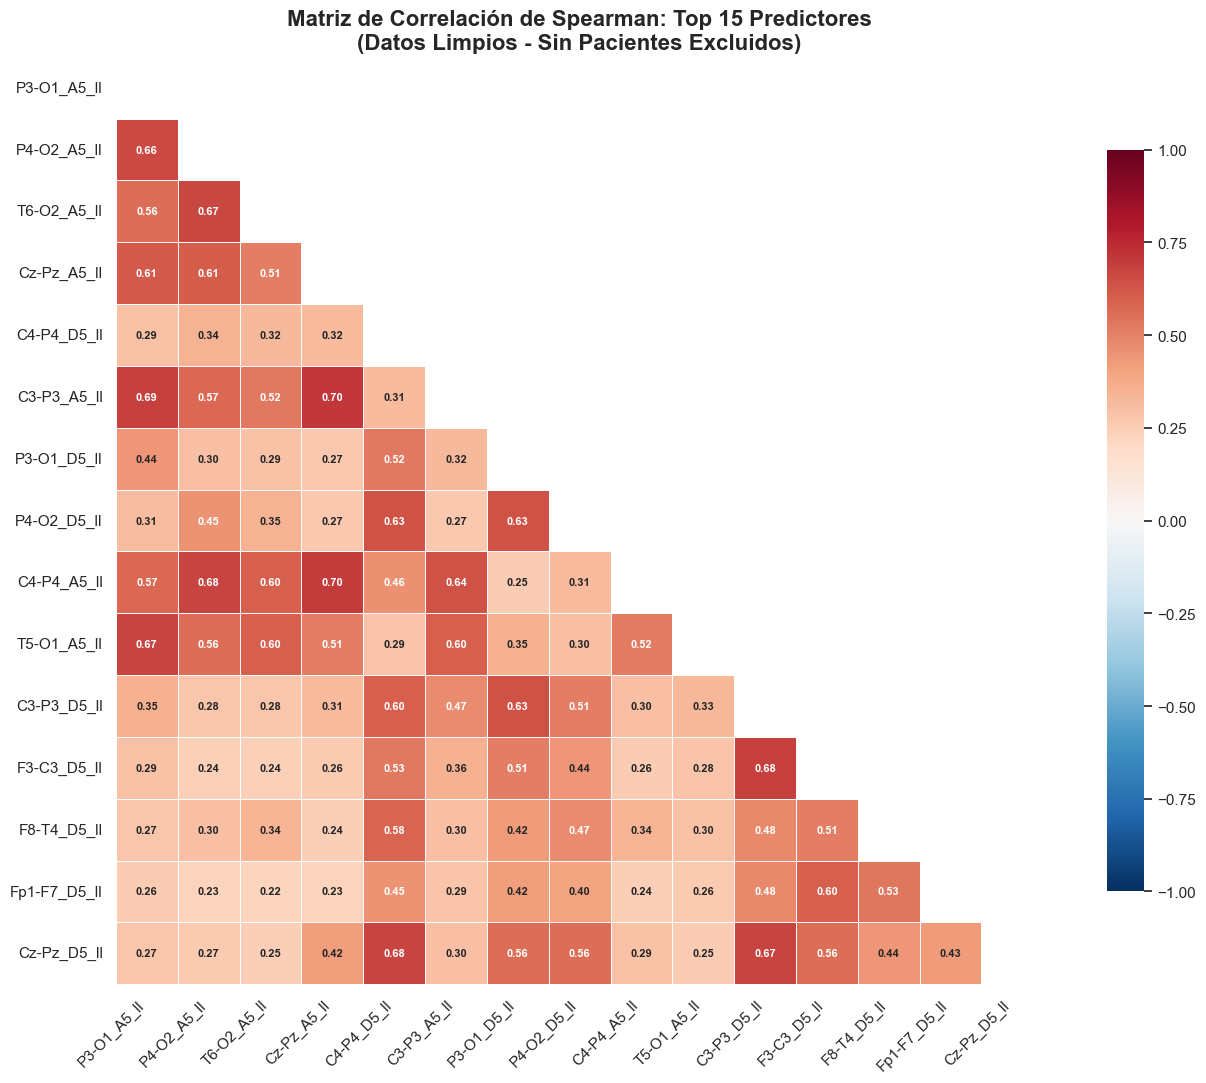

In [9]:
FEATURES_PATH = r"04_TUSZ_Features_ML\version=v1_raw_labels"

TOP_15_LIST = [
    'P3-O1_A5_ll', 'P4-O2_A5_ll', 'T6-O2_A5_ll', 'Cz-Pz_A5_ll', 
    'C4-P4_D5_ll', 'C3-P3_A5_ll', 'P3-O1_D5_ll', 'P4-O2_D5_ll', 
    'C4-P4_A5_ll', 'T5-O1_A5_ll', 'C3-P3_D5_ll', 'F3-C3_D5_ll', 
    'F8-T4_D5_ll', 'Fp1-F7_D5_ll', 'Cz-Pz_D5_ll'
]

# Usamos la variable que ya tienes definida
pacientes_excluidos = matriz_fallos['paciente'].unique().tolist()

# Ejecutar el análisis
matriz_corr_final = calcular_correlacion_top15(FEATURES_PATH, TOP_15_LIST, pacientes_excluidos)

📡 Cargando subconjunto de datos para PCA...


Procesando archivos: 100%|█████████████████████████████████████████████████████████| 1641/1641 [01:15<00:00, 21.77it/s]


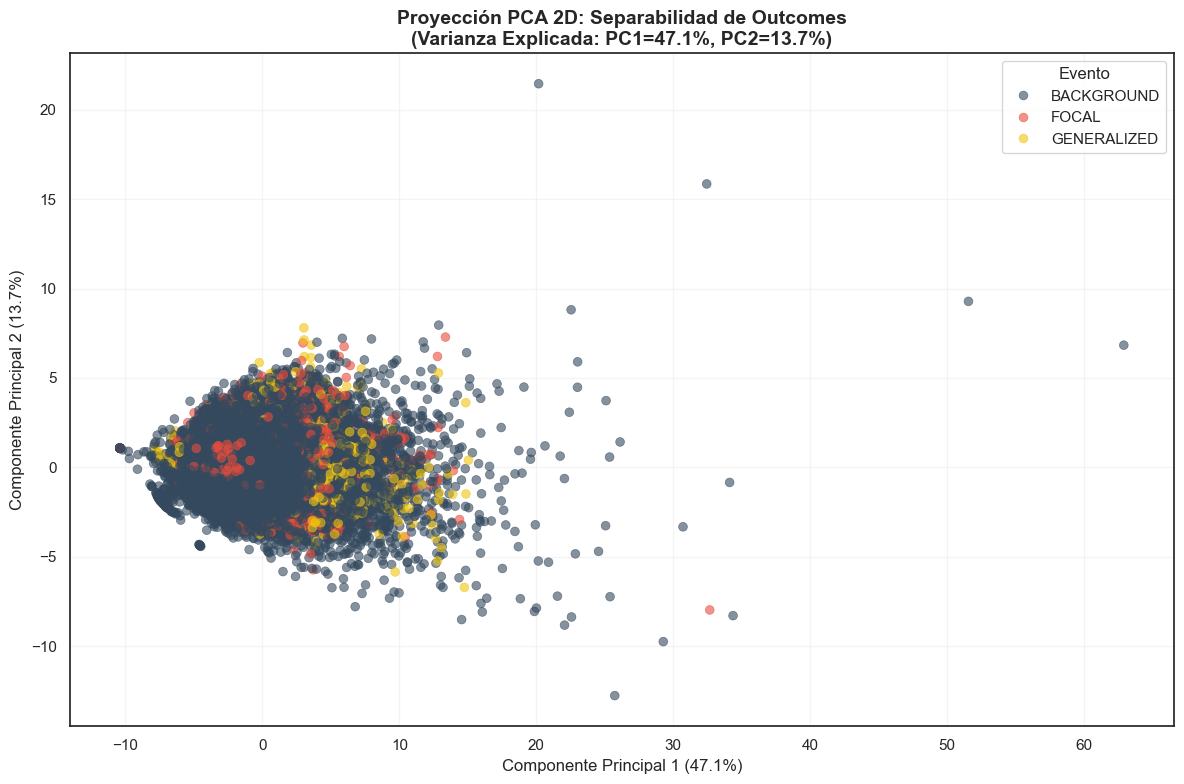

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import tqdm

# --- CONFIGURACIÓN ---
FEATURES_PATH = r"04_TUSZ_Features_ML\version=v1_raw_labels"
TOP_15 = [
    'P3-O1_A5_ll', 'P4-O2_A5_ll', 'T6-O2_A5_ll', 'Cz-Pz_A5_ll', 
    'C4-P4_D5_ll', 'C3-P3_A5_ll', 'P3-O1_D5_ll', 'P4-O2_D5_ll', 
    'C4-P4_A5_ll', 'T5-O1_A5_ll', 'C3-P3_D5_ll', 'F3-C3_D5_ll', 
    'F8-T4_D5_ll', 'Fp1-F7_D5_ll', 'Cz-Pz_D5_ll'
]
# Usamos tu lista de pacientes excluidos
lista_excluidos = pacientes_excluidos 

LABEL_MAPPING = {
    'bckg': 'BACKGROUND',
    'fnsz': 'FOCAL', 'cpsz': 'FOCAL', 'spsz': 'FOCAL',
    'gnsz': 'GENERALIZED', 'tcsz': 'GENERALIZED', 'tnsz': 'GENERALIZED', 
    'absz': 'GENERALIZED', 'mysz': 'GENERALIZED'
}

def run_pca_analysis(path_root, features, excluded_ids):
    path = Path(path_root).resolve()
    all_files = list(path.rglob("*.parquet"))
    data_list = []

    print("📡 Cargando subconjunto de datos para PCA...")
    for f in tqdm.tqdm(all_files, desc="Procesando archivos"):
        if f.parent.name in excluded_ids:
            continue
        try:
            # Cargamos solo lo necesario
            df_temp = pd.read_parquet(f, columns=['label'] + features)
            df_temp['class'] = df_temp['label'].map(lambda x: LABEL_MAPPING.get(x, 'BACKGROUND'))
            # Submuestreo para no saturar memoria y balancear pacientes
            data_list.append(df_temp.sample(n=min(len(df_temp), 50), random_state=42))
        except:
            continue
    
    full_df = pd.concat(data_list, ignore_index=True)
    
    # 1. Preparación de matrices
    X = full_df[features].dropna()
    y = full_df.loc[X.index, 'class']
    
    # 2. Estandarización (Media 0, Varianza 1)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 3. Aplicar PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # 4. Graficar
    plt.figure(figsize=(12, 8))
    sns.set_style("white")
    
    # Paleta de colores consistente
    palette = {"BACKGROUND": "#34495e", "FOCAL": "#e74c3c", "GENERALIZED": "#f1c40f"}
    
    scatter = sns.scatterplot(
        x=X_pca[:, 0], 
        y=X_pca[:, 1], 
        hue=y, 
        palette=palette, 
        alpha=0.6, 
        edgecolor=None,
        s=40
    )
    
    var_exp = pca.explained_variance_ratio_
    plt.title(f"Proyección PCA 2D: Separabilidad de Outcomes\n(Varianza Explicada: PC1={var_exp[0]:.1%}, PC2={var_exp[1]:.1%})", 
              fontsize=14, fontweight='bold')
    plt.xlabel(f"Componente Principal 1 ({var_exp[0]:.1%})", fontsize=12)
    plt.ylabel(f"Componente Principal 2 ({var_exp[1]:.1%})", fontsize=12)
    plt.grid(alpha=0.2)
    plt.legend(title="Evento", loc='best')
    
    plt.tight_layout()
    plt.show()
    
    return pca, full_df

# Ejecución
pca_model, df_pca_total = run_pca_analysis(FEATURES_PATH, TOP_15, lista_excluidos)

🌀 Calculando proyección no lineal (t-SNE)...


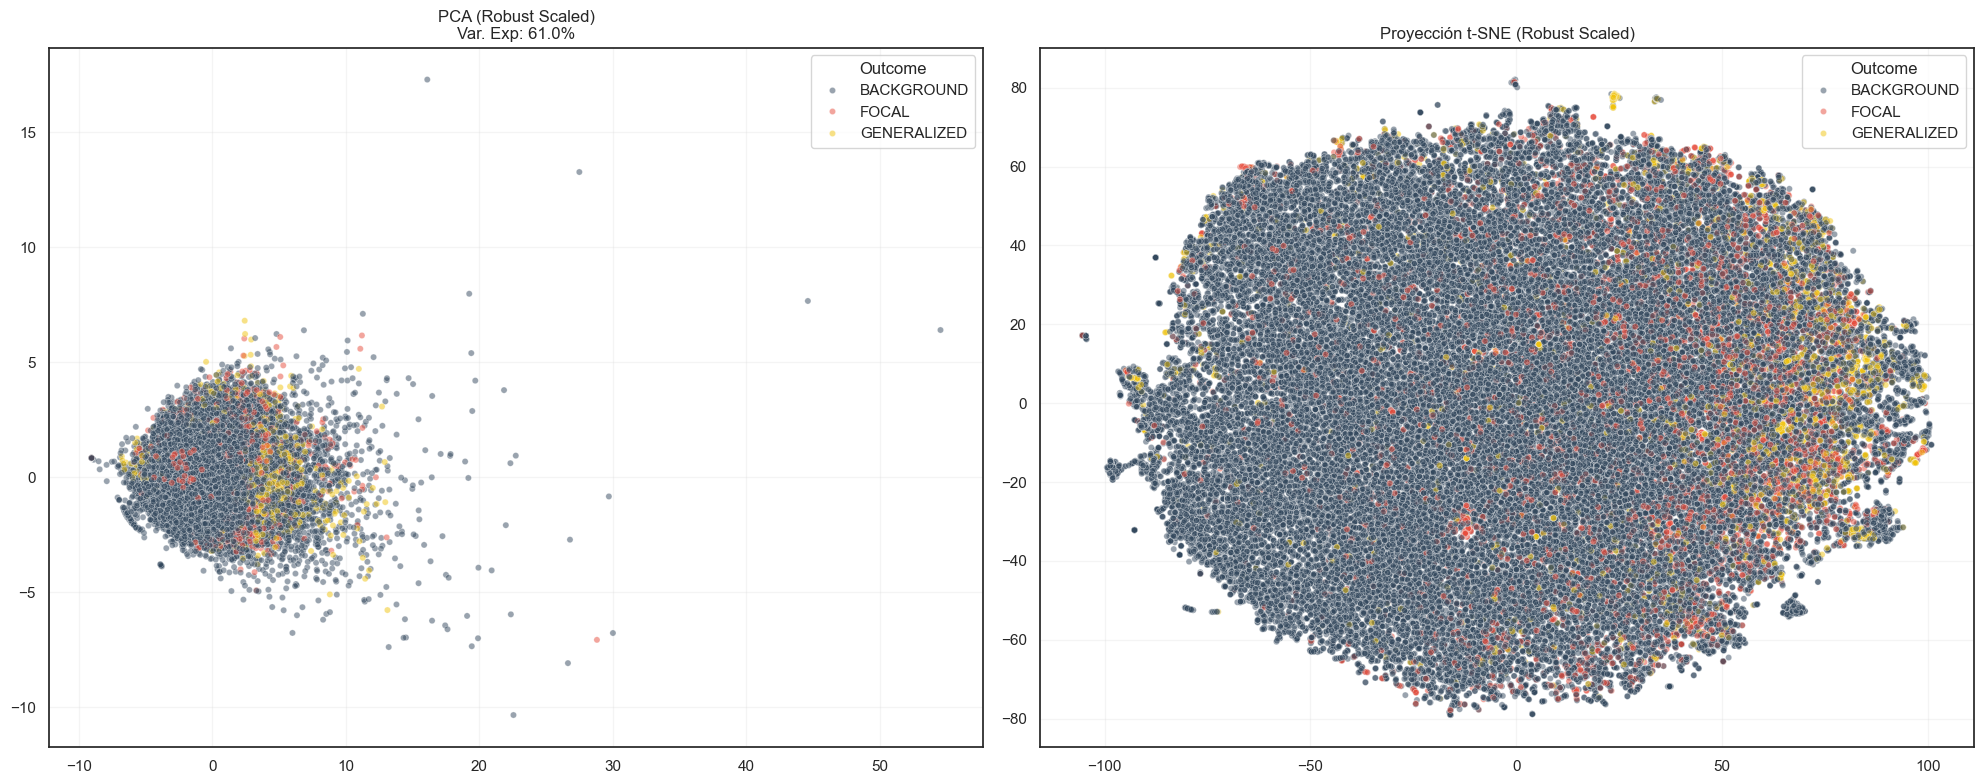

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from sklearn.manifold import TSNE  # Backup por si no hay UMAP
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

def run_robust_projection(df, features, target_col='class'):
    # 1. Limpieza de NaNs y Selección
    X = df[features].dropna()
    y = df.loc[X.index, target_col]
    
    # 2. ESCALAMIENTO ROBUSTO (Mediana y IQR)
    # Esto ignora los outliers de los picos de señal
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 3. PCA (Referencia Lineal)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # 4. UMAP o t-SNE (Referencia No Lineal)
    print(f"🌀 Calculando proyección no lineal ({'UMAP' if HAS_UMAP else 't-SNE'})...")
    if HAS_UMAP:
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
        X_non_linear = reducer.fit_transform(X_scaled)
        title_non_linear = "Proyección UMAP"
    else:
        reducer = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
        X_non_linear = reducer.fit_transform(X_scaled)
        title_non_linear = "Proyección t-SNE"

    # --- VISUALIZACIÓN ---
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    palette = {"BACKGROUND": "#34495e", "FOCAL": "#e74c3c", "GENERALIZED": "#f1c40f"}
    
    # Plot PCA
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette=palette, alpha=0.5, ax=axes[0], s=20)
    axes[0].set_title(f"PCA (Robust Scaled)\nVar. Exp: {pca.explained_variance_ratio_.sum():.1%}")
    
    # Plot No-Lineal (UMAP/t-SNE)
    sns.scatterplot(x=X_non_linear[:,0], y=X_non_linear[:,1], hue=y, palette=palette, alpha=0.5, ax=axes[1], s=20)
    axes[1].set_title(f"{title_non_linear} (Robust Scaled)")
    
    for ax in axes:
        ax.grid(alpha=0.2)
        ax.legend(title="Outcome")

    plt.tight_layout()
    plt.show()

# --- EJECUCIÓN ---
# Reutilizamos el 'df_pca_total' que generamos en el paso anterior
run_robust_projection(df_pca_total, TOP_15)